<a href="https://colab.research.google.com/github/sendang-a-kinanti/Business-Analytics-Portfolio/blob/main/E_commerce_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

# Load the dataset from the CSV file
df = pd.read_csv('Ecommerce_Sales_Data_2024_2025.csv')

# Preview the first 5 rows of the data
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [ ]:
# Check dataset structure, columns, and data types
df.info()

# Generate descriptive statistics for numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB


,Order ID,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
std,1443.520003,1.413133,22831.783946,7.084662,85108.208202,14897.684916
min,10001.000000,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,5.000000,79998.000000,20.000000,398485.000000,89688.440000


/tmp/ipykernel_7335/1438615399.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=profit_category, x='Category', y='Profit', palette='magma')


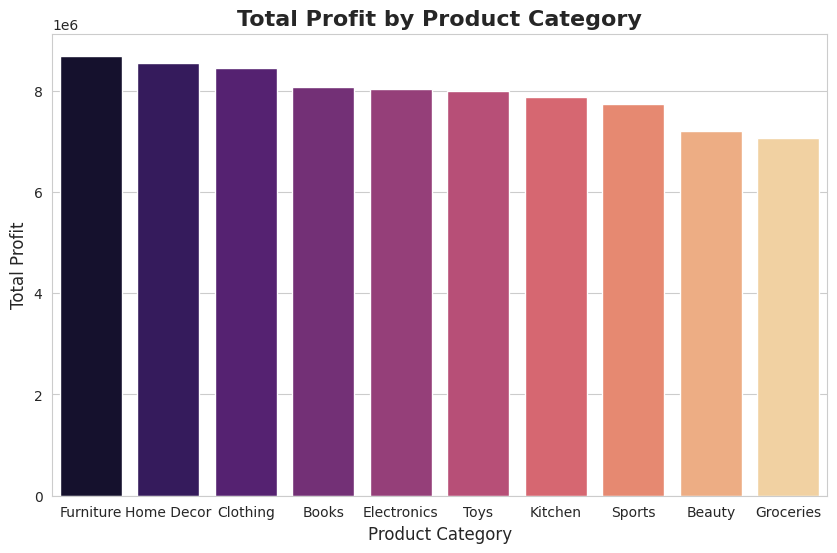

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group the data by 'Category' and calculate total profit, then sort it
profit_category = df.groupby('Category')['Profit'].sum().reset_index()
profit_category = profit_category.sort_values(by='Profit', ascending=False)

# 2. Set the visual style and canvas size
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 3. Create a bar chart showing profit by category
# Using 'magma' palette for a premium and professional business look
sns.barplot(data=profit_category, x='Category', y='Profit', palette='magma')

# 4. Add professional English labels and a bold title
plt.title('Total Profit by Product Category', fontsize=16, fontweight='bold')
plt.xlabel('Product Category', fontsize=12)
plt.ylabel('Total Profit', fontsize=12)

# 5. Display the final plot
plt.show()

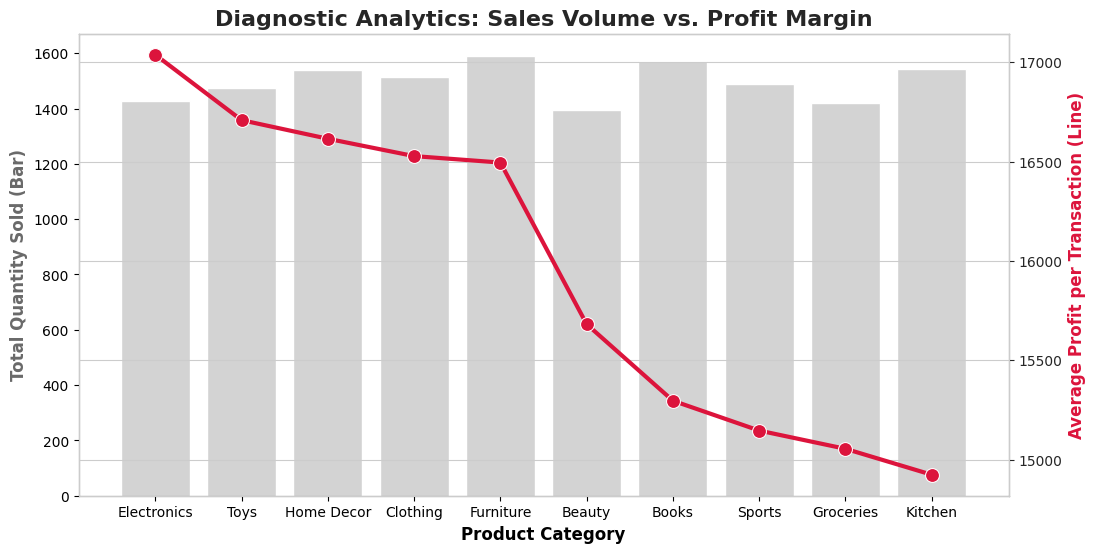

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate data: Calculate Total Quantity Sold AND Average Profit per transaction
diagnostic_df = df.groupby('Category').agg(
    Total_Quantity=('Quantity', 'sum'),
    Average_Profit=('Profit', 'mean')
).reset_index()

# Sort by Average Profit to see which item gives the highest margin
diagnostic_df = diagnostic_df.sort_values(by='Average_Profit', ascending=False)

# 2. Set up the canvas for a Dual-Axis Chart
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_style("whitegrid")

# 3. Create Bar Chart for Total Quantity (Volume) on the left Y-axis
sns.barplot(data=diagnostic_df, x='Category', y='Total_Quantity', color='lightgray', ax=ax1)
ax1.set_ylabel('Total Quantity Sold (Bar)', color='dimgray', fontsize=12, fontweight='bold')
ax1.set_xlabel('Product Category', fontsize=12, fontweight='bold')

# 4. Create Line Chart for Average Profit (Margin) on the right Y-axis
ax2 = ax1.twinx()  # This is the "magic" code to create a second Y-axis
sns.lineplot(data=diagnostic_df, x='Category', y='Average_Profit', color='crimson', marker='o', linewidth=3, markersize=10, ax=ax2)
ax2.set_ylabel('Average Profit per Transaction (Line)', color='crimson', fontsize=12, fontweight='bold')

# 5. Add Professional Title
plt.title('Diagnostic Analytics: Sales Volume vs. Profit Margin', fontsize=16, fontweight='bold')

# Display the plot
plt.show()